# AI Worker Burnout ML

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## Data loading

In [2]:
df = pd.read_csv('../data/ai_worker_burnout_attrition_2026.csv')

In [3]:
print(df.dtypes)

employee_id                        object
job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object


In [4]:
df.head(20)

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
5,EMP0006,Data Analyst,12,Self-taught,Germany,Healthtech,Large (1000-5000),On-site,19,106,...,5,5.7,23,Optimizing,6.7,66,61,3.5,Medium,Low
6,EMP0007,AI Ethics Officer,12,PhD,USA,Gaming,Enterprise (5000+),Fully Remote,46,154,...,1,2.7,45,Optimizing,8.1,54,33,3.5,High,Low
7,EMP0008,Data Scientist,19,Bootcamp,Singapore,Consulting,Enterprise (5000+),Hybrid,44,54,...,7,4.7,46,Optimizing,9.1,43,57,2.9,Low,Medium
8,EMP0009,Data Analyst,6,Master,Germany,Fintech,Mid (200-1000),Hybrid,42,55,...,7,2.8,56,Experimenting,8.1,69,52,2.8,Low,Medium
9,EMP0010,Prompt Engineer,2,Bachelor,Netherlands,Gaming,Large (1000-5000),On-site,15,61,...,5,1.8,8,Optimizing,9.7,64,27,3.8,Medium,Low


In [5]:
df = df.drop(columns=['employee_id'])

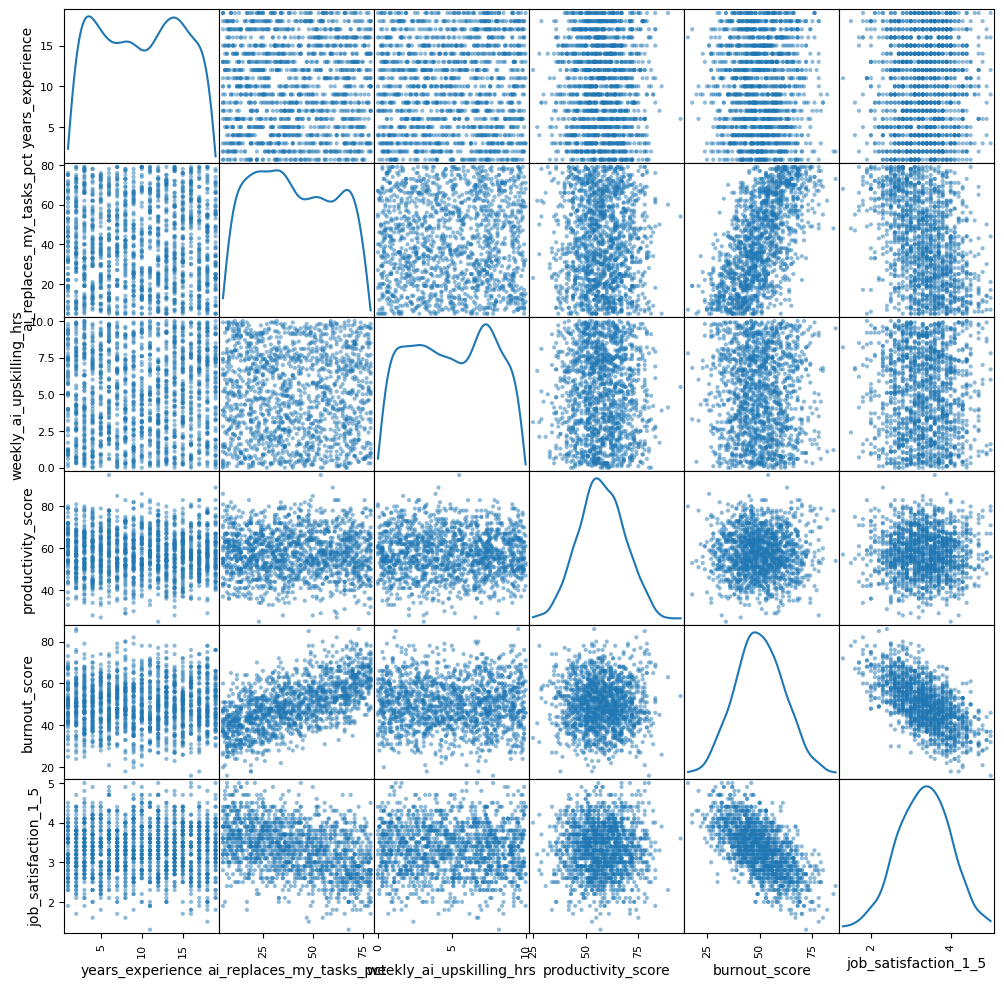

In [6]:
from pandas.plotting import scatter_matrix

selected_cols = [
    'years_experience',
    'ai_replaces_my_tasks_pct', 
    'weekly_ai_upskilling_hrs', 
    'productivity_score', 
    'burnout_score', 
    'job_satisfaction_1_5'
]

fig = plt.figure(1, figsize=(12, 12))
fig.clf()
ax = fig.gca()
scatter_matrix(df[selected_cols], alpha=0.5, diagonal='kde', ax=ax)
plt.show()

<Axes: >

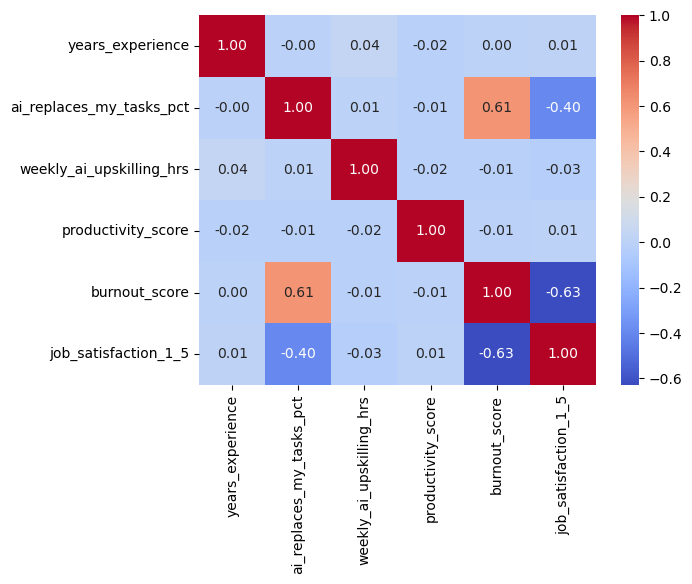

In [7]:
correlation_matrix = df[selected_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

## AI Worker Burnout Attrition Modeling

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df.copy().drop(['attrition_risk'], axis=1)
y = df.copy()['attrition_risk']

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'attrition_risk' in cat_cols:
    cat_cols.remove('attrition_risk')

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Logistic Regression

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['years_experience',
                                                   'team_size', 'salary_usd_k',
                                                   'ai_tools_used_per_day',
                                                   'hours_with_ai_assistance_daily',
                                                   'ai_replaces_my_tasks_pct',
                                                   'weekly_ai_upskilling_hrs',
                                                   'productivity_score',
                                                   'burnout_score',
                                                   'job_satisfaction_1_5']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_role',
                                                   'education_level', 'country',
                                                   'industry', 'company_size',
                                                   'remote_work_type',
                                                   'primary_ai_tool',
                                                   'ai_adoption_stage',
                                                   'fear_of_ai_replacement'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.multiclass import unique_labels

def evaluate_model(model, X_train, X_test, y_train, y_test, X_full=None, y_full=None):
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    if X_full is not None and y_full is not None:
        print('Model score: \t{:.4f}'.format(model.score(X_full, y_full)))
        
    print('Score against training data: \t{:.4f}'.format(model.score(X_train, y_train)))
    
    print('Accuracy score: \t{:.4f}'.format(accuracy))
    print('Precision score: \t{:.4f}'.format(precision))
    print('Recall score: \t{:.4f}'.format(recall))
    print('F1 score: \t{:.4f}'.format(f1))
    print('\nConfusion matrix: \n', conf_matrix)
    
    classes = unique_labels(y_test, y_pred)
    print('\nThe order of classes is : ', classes)

In [12]:
evaluate_model(log_model, X_train, X_test, y_train, y_test, X, y)

Model score: 	0.8667
Score against training data: 	0.8683
Accuracy score: 	0.8600
Precision score: 	0.8561
Recall score: 	0.8600
F1 score: 	0.8573

Confusion matrix: 
 [[  5   0   8]
 [  0 126  15]
 [  4  15 127]]

The order of classes is :  ['High' 'Low' 'Medium']


In [13]:
# Accuracy: 86% of predicitions are correct, no strong overfitting
# Precision: 85.6% of predictions are correct
# Recall: 86, model captures most true cases
# F1: 85.7 entails balanced precision and recall

# Based on the confusion matrix, there seems to be a strong class imbalance

In [14]:
df['attrition_risk'].value_counts()

attrition_risk
Low       724
Medium    691
High       85
Name: count, dtype: int64

In [15]:
# The class imbalance may affect the model's accuracy, so in the future it may 
# be good using LogisticRegression(class_weight='balanced')

### Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300, 
        max_depth = 10, 
        min_samples_split=10,
        min_samples_leaf=5, 
        class_weight='balanced',
        random_state=42))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['years_experience',
                                                   'team_size', 'salary_usd_k',
                                                   'ai_tools_used_per_day',
                                                   'hours_with_ai_assistance_daily',
                                                   'ai_replaces_my_tasks_pct',
                                                   'weekly_ai_upskilling_hrs',
                                                   'productivity_score',
                                                   'burnout_score',
                                                   'job_satisfaction_1_5']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_role',
                                                   'education_level', 'country',
                                                   'industry', 'company_size',
                                                   'remote_work_type',
                                                   'primary_ai_tool',
                                                   'ai_adoption_stage',
                                                   'fear_of_ai_replacement'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        random_state=42))])

In [17]:
evaluate_model(rf_model, X_train, X_test, y_train, y_test, X, y)

Model score: 	0.9207
Score against training data: 	0.9400
Accuracy score: 	0.8433
Precision score: 	0.8439
Recall score: 	0.8433
F1 score: 	0.8417

Confusion matrix: 
 [[  7   0   6]
 [  0 124  17]
 [  1  23 122]]

The order of classes is :  ['High' 'Low' 'Medium']


In [18]:
# Accuracy: 84% of predictions are correct
# Precision: 84% of predicitions are correct
# Recalls: 84.3, captures most true cases
# F1 score: 84.4 entails balanced precision and recall

# Balanced weighting has traded some of the overall accuracy to improve rare
# class recall

# The order of the row are High, then Low, and then Medium
# The confustion matrix shows that for High attrition risk, TP is 7 (correctly
# predicted as High), and FN is 6 (predicted as Medium)

# For the Low attrition risk, TP is 124, and FN is 17 (predicted as Medium)

# For the Medium attrition risk, TP is 122, and total FN is 24 (where 23 have 
# been predicted as Low, and 1 predicted as High)

In [19]:
# The author of the dataset suggested using clustering by segmenting workers by
# AI adoption behaviour and wellbeing patterns
# This would require selecting more specific variables and see if there are 
# groups of workers who share similar AI usage patterns and wellbeing outcomes
# attrition_risk is not used anymore as it is unsupervised learning

### Clustering

In [20]:
features = df[['ai_tools_used_per_day', 'hours_with_ai_assistance_daily', 'burnout_score', 'job_satisfaction_1_5']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

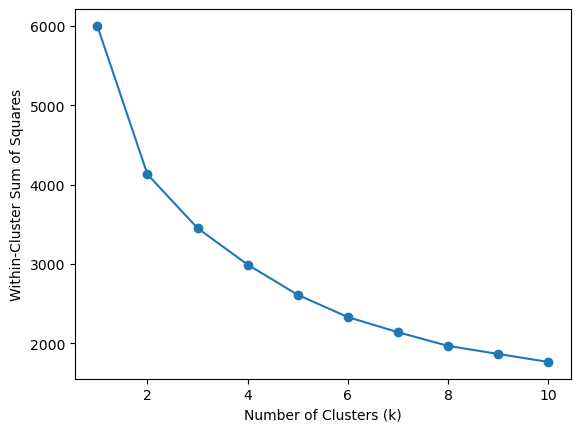

In [21]:
from sklearn.cluster import KMeans

# Within-Cluster Sum of Squares
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares')
plt.show()

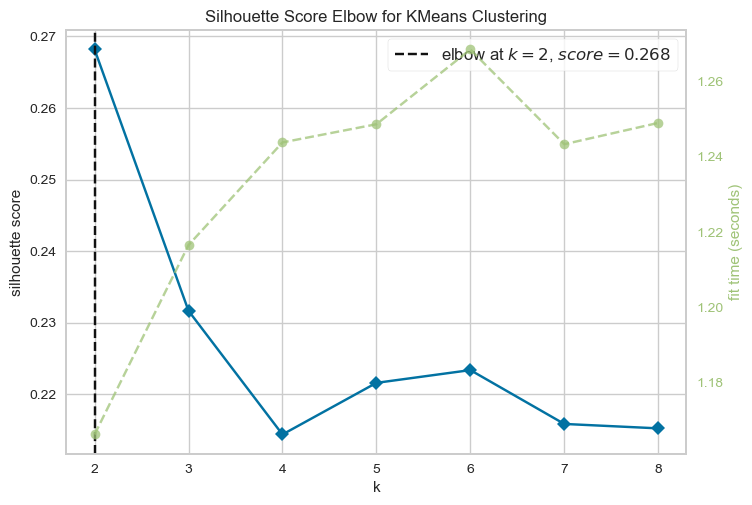

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [22]:
# from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer

# scores = []

# for k in range(2, 11):
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     labels = kmeans.fit_predict(X_scaled)
#     score = silhouette_score(X_scaled, labels)
#     scores.append(score)
    
    
# plt.plot(range(2, 11), scores, marker='o')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Silhouette Score')
# plt.title('Silhouette Score to choose k')
# plt.show()

visualizer = KElbowVisualizer(KMeans(n_init=10, random_state=42), k=(2, 9), metric='silhouette', timing=False)
visualizer.fit(X_scaled)
visualizer.show()

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters + 1

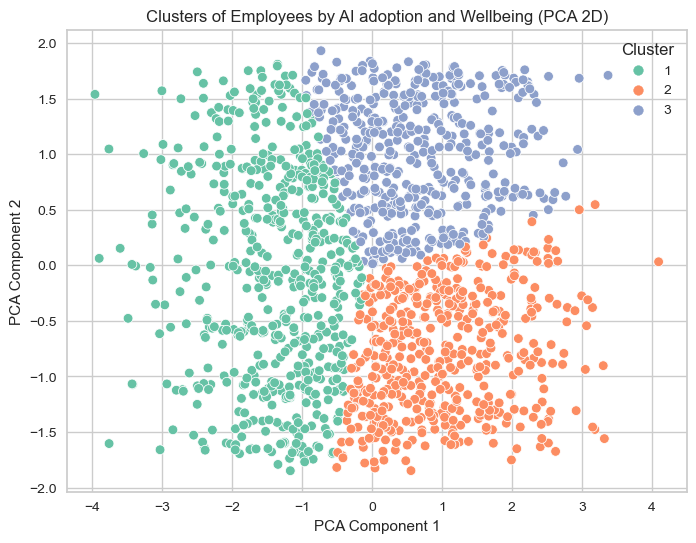

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'], palette='Set2')
plt.title('Clusters of Employees by AI adoption and Wellbeing (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

In [25]:
df.groupby('cluster')[[
    'ai_tools_used_per_day',
    'hours_with_ai_assistance_daily',
    'burnout_score',
    'job_satisfaction_1_5',
    'productivity_score'
]].mean()

,ai_tools_used_per_day,hours_with_ai_assistance_daily,burnout_score,job_satisfaction_1_5,productivity_score
cluster,,,,,
1,4.180851,5.702837,60.171986,2.800532,57.952128
2,5.658436,3.494650,42.744856,3.769547,60.641975
3,2.168889,3.190667,45.277778,3.534667,53.684444


In [26]:
# Cluster 1 uses 4 AI tools per day, spending approximately 6 hours a day, 
# yields 60% burnout score, with a job satisifaction average of 2.8 out of 5,
# and 57.9% productivity score

# This cluster is about employees that spend most of their time working with AI
# tools and experience significantly higher burnout and lower job satisfaction
# ============================================================================

# Cluster 2 uses approximately 6 tools a day, spending 3.5 hours a day, yields
# 42.7% burnout score, with a job satisfaction of 3.8 out of 5, and 60.6%
# productivity score

# This cluster is about employees that use AI more efficiently. While they use
# many tools, they do not spend too much time with them. They use these 
# efficiently because the productivity is increased, without increasing too
# much burnout
# ============================================================================

# Cluster 3 uses approximately 2 tools a day, spending 3 hours a day, yields
# 45% burnout score, with a job satisfaction of 3.5 out of 5, and 53.7%
# productivity score

# This cluster is about employees that adopt fewer AI tools, and also show 
# slightly less productivity, suggesting that limitedAI adoption may reduce
# potential producivity benefits

In [27]:
pd.crosstab(df['cluster'], df['attrition_risk'])

attrition_risk,High,Low,Medium
cluster,,,
1,73,98,393
2,5,334,147
3,7,292,151


In [28]:
pd.crosstab(df['cluster'], df['attrition_risk'], normalize='index').mul(100).round(2)

attrition_risk,High,Low,Medium
cluster,,,
1,12.94,17.38,69.68
2,1.03,68.72,30.25
3,1.56,64.89,33.56


In [29]:
table = pd.crosstab(df['cluster'], df['attrition_risk'], normalize='index').mul(100).round(2).astype(str) + '%'

In [30]:
table

attrition_risk,High,Low,Medium
cluster,,,
1,12.94%,17.38%,69.68%
2,1.03%,68.72%,30.25%
3,1.56%,64.89%,33.56%


In [31]:
# The key insight is that AI usage alone does not cause burnout, but rather long
# hours using AI cause higher burnout, and using more AI tools efficiently lead
# to higher productivity and job satisfaction.
# This pattern is also found on the regression and the initial EDA.